# Problem 2.16: 1D Row & Column Filtering and 2D Separability

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
In this problem use the Lena image shown in Figure 2.23 which is available in the book toolbox.
* **(a)** Load the Lena image in MATLAB/Python and display using `imshow`.
* **(b)** Consider the 1D impulse response $h[n] = \frac{1}{5}\{1, 1, 1, 1, 1\}$ with origin at center ($n \in [-2, 2]$). Using it perform 1D convolution along each row of the Lena image and display the resulting blurred image. Comment on the result.
* **(c)** Using the above impulse response now perform convolution along each column of the Lena image and display the resulting blurred image. Compare this image with the one in part (b).
* **(d)** Using $h[n]$ perform convolution along each column of the result image of part (b) and display the resulting image. How does it compare with the above two result images as well as the one in part (c) in Problem 15?

In [2]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.signal import convolve2d


## (a) Load and Display Original Image
Define the 1D impulse response $h[n] = \frac{1}{5} [1, 1, 1, 1, 1]$ centered at $n=0$ ($n = -2, -1, 0, 1, 2$).

Image size: 512 x 512
1D kernel h[n]: [0.2 0.2 0.2 0.2 0.2]


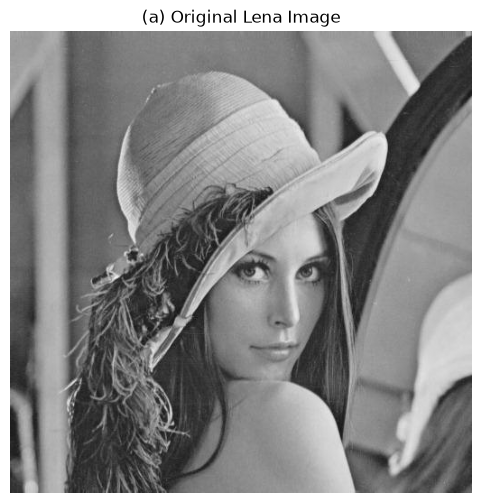

In [4]:
image_path = Path('lena.jpg')
if not image_path.exists():
    import urllib.request
    url = 'https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg'
    urllib.request.urlretrieve(url, image_path)

img = Image.open(image_path).convert('L')
x = np.array(img, dtype=np.float64)
num_rows, num_cols = x.shape

# 1D 5-point moving average filter kernel
h = np.ones(5, dtype=np.float64) / 5.0

print(f'Image size: {num_rows} x {num_cols}')
print(f'1D kernel h[n]: {h}')

plt.figure(figsize=(6, 6))
plt.imshow(x, cmap='gray', vmin=0, vmax=255)
plt.title('(a) Original Lena Image')
plt.axis('off')
plt.show()


## (b) 1D Convolution Along Each Row (Horizontal Filtering)
Convolve each row $i$ of the image with the 1D impulse response $h[n]$:
$$
y_h[m, n] = \sum_{l=-2}^{2} h[l] x[m, n - l]
$$

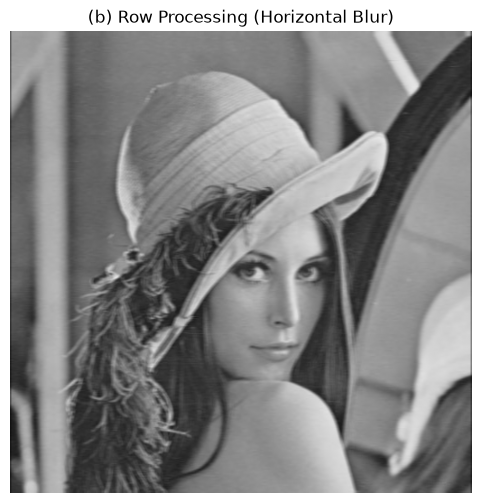

In [6]:
y_row = np.zeros_like(x)
for i in range(num_rows):
    y_row[i, :] = np.convolve(x[i, :], h, mode='same')

plt.figure(figsize=(6, 6))
plt.imshow(y_row, cmap='gray', vmin=0, vmax=255)
plt.title('(b) Row Processing (Horizontal Blur)')
plt.axis('off')
plt.show()


## (c) 1D Convolution Along Each Column (Vertical Filtering)
Convolve each column $j$ of the image with $h[n]$:
$$
y_v[m, n] = \sum_{k=-2}^{2} h[k] x[m - k, n]
$$

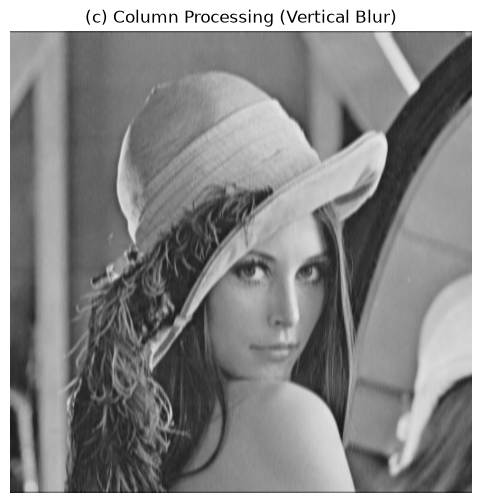

In [8]:
y_col = np.zeros_like(x)
for j in range(num_cols):
    y_col[:, j] = np.convolve(x[:, j], h, mode='same')

plt.figure(figsize=(6, 6))
plt.imshow(y_col, cmap='gray', vmin=0, vmax=255)
plt.title('(c) Column Processing (Vertical Blur)')
plt.axis('off')
plt.show()


## (d) Sequential Row then Column Convolution
Convolve the result of part (b) along each column using $h[n]$:
$$
y_{hv}[m, n] = \sum_{k=-2}^{2} h[k] y_h[m - k, n] = \sum_{k=-2}^{2} \sum_{l=-2}^{2} (h[k] h[l]) x[m - k, n - l]
$$

Maximum absolute difference between 16(d) and 15(c): 1.14e-13
Are they identical within floating-point tolerance? True


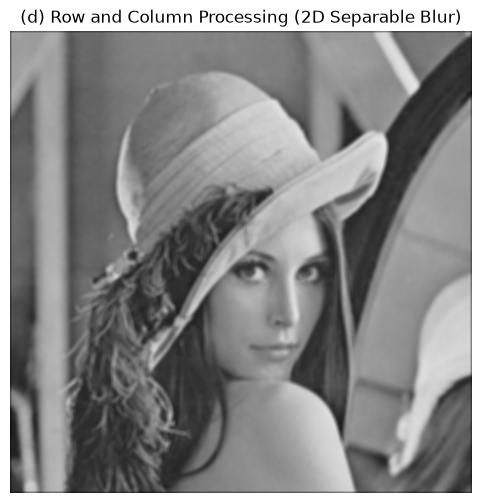

In [10]:
y_row_col = np.zeros_like(x)
for j in range(num_cols):
    y_row_col[:, j] = np.convolve(y_row[:, j], h, mode='same')

# Compute 2D 5x5 filter from Problem 15(c) for comparison
h_2d = np.ones((5, 5), dtype=np.float64) / 25.0
y_prob15c = convolve2d(x, h_2d, mode='same', boundary='fill', fillvalue=0)

diff = np.max(np.abs(y_row_col - y_prob15c))
print(f'Maximum absolute difference between 16(d) and 15(c): {diff:.2e}')
print(f'Are they identical within floating-point tolerance? {np.allclose(y_row_col, y_prob15c)}')

plt.figure(figsize=(6, 6))
plt.imshow(y_row_col, cmap='gray', vmin=0, vmax=255)
plt.title('(d) Row and Column Processing (2D Separable Blur)')
plt.axis('off')
plt.show()


## Comparison of All Results

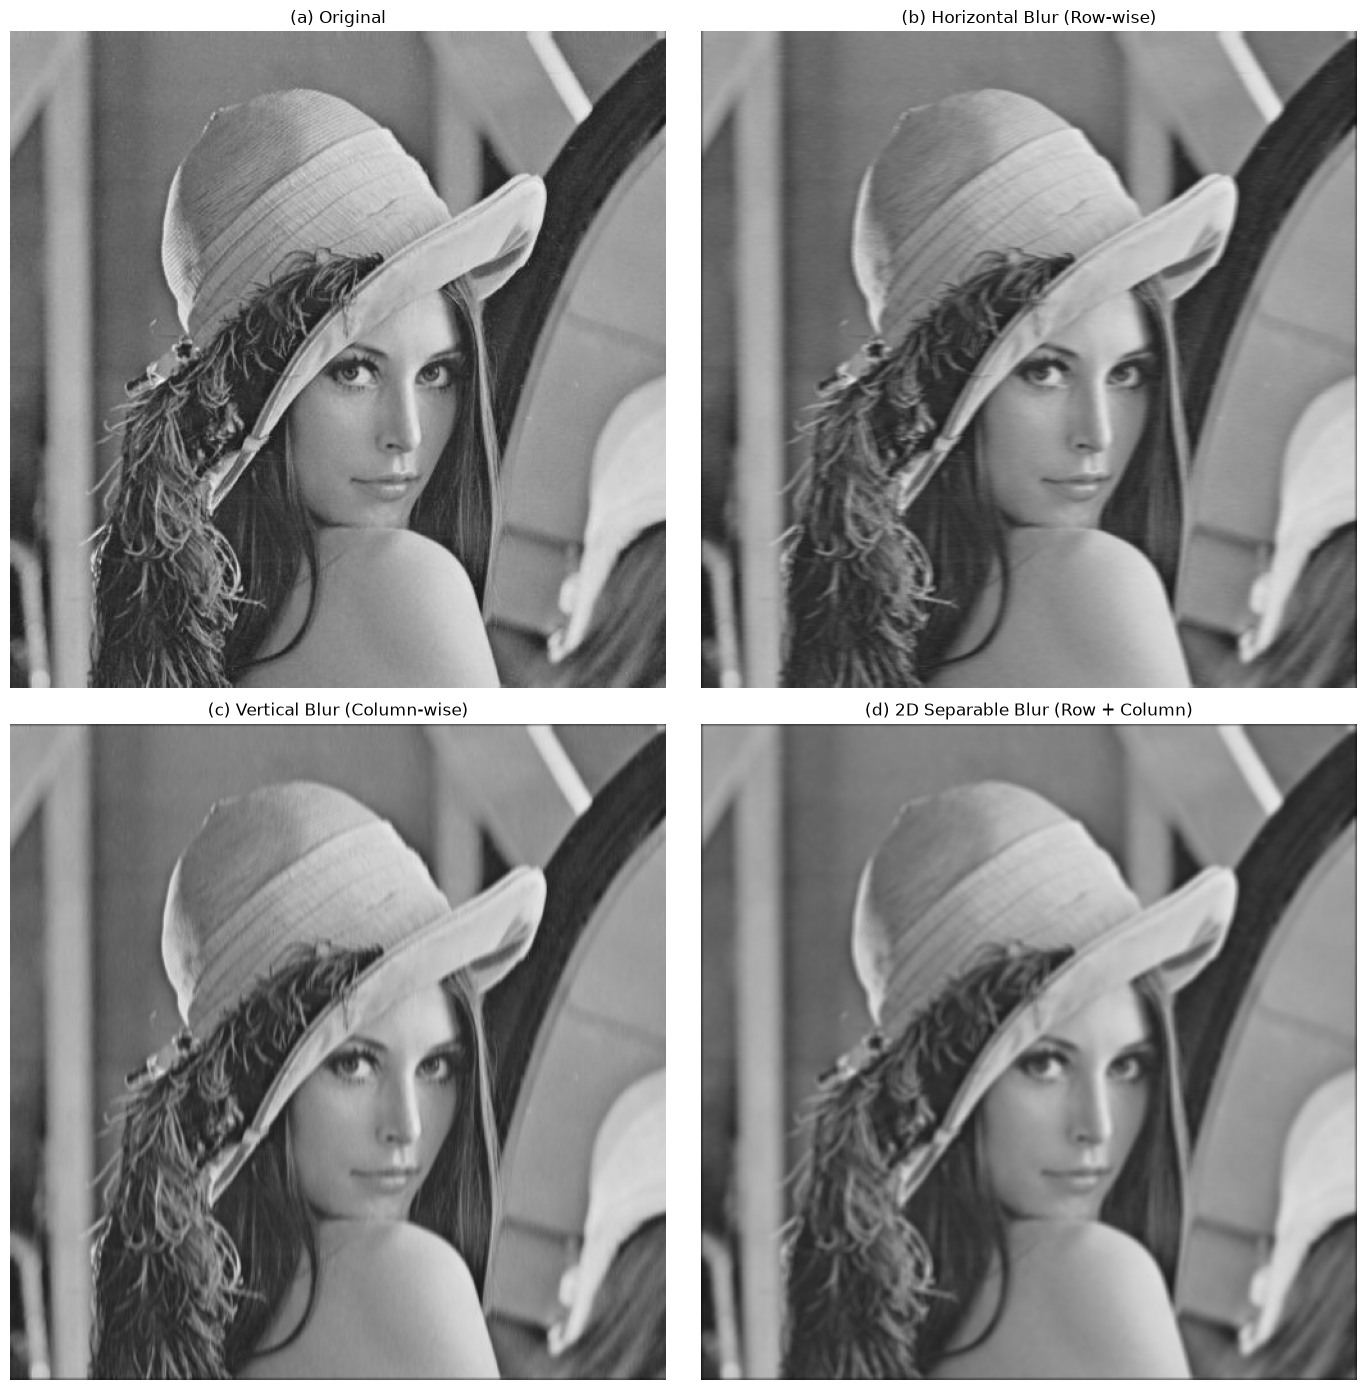

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

axes[0, 0].imshow(x, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('(a) Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(y_row, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('(b) Horizontal Blur (Row-wise)')
axes[0, 1].axis('off')

axes[1, 0].imshow(y_col, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('(c) Vertical Blur (Column-wise)')
axes[1, 0].axis('off')

axes[1, 1].imshow(y_row_col, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('(d) 2D Separable Blur (Row + Column)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
